# 07. Panel Data Complications

Panel data feels powerful because we observe units repeatedly over time.

That power is real. Repeated observations let us remove time-invariant unit differences, absorb common shocks, study dynamics, and visualize pre-treatment trajectories. But panels also create traps:

- serially correlated outcomes,
- persistent treatment,
- staggered adoption,
- dynamic treatment effects,
- anticipation,
- time-varying confounding,
- attrition and unbalanced panels,
- misleading event-study coefficients.

This notebook is about the practical causal workflow for panel data. We will simulate common designs, estimate fixed-effects and difference-in-differences models, and diagnose where simple panel regressions stop answering the decision question.


## Learning Goals

By the end of this notebook, you should be able to:

- Explain what unit and time fixed effects do and do not solve.
- State the parallel trends assumption for difference-in-differences.
- Diagnose serial correlation and why conventional standard errors can be too optimistic.
- Recognize Nickell bias in dynamic fixed-effects models with short panels.
- Explain why staggered adoption creates complications for two-way fixed effects.
- Estimate simple group-time treatment effects with not-yet-treated comparison units.
- Interpret event-study plots carefully under dynamic and heterogeneous effects.
- Identify anticipation, time-varying confounding, and attrition as panel-data threats.
- Write a professional panel-data causal memo for an industry project.


## 1. Setup

We will use pandas, numpy, statsmodels, seaborn, matplotlib, and Graphviz.


In [1]:
# Import the analysis, modeling, and plotting tools used throughout this notebook.
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def coef_row(model, term):
    """Extract one coefficient and uncertainty interval from a fitted panel model.
    
    Inputs:
    - `model`: fitted statistical or machine-learning model whose coefficients or predictions are being used.
    - `term`: coefficient name whose estimate and uncertainty should be extracted.
    Returns: a pandas Series with estimate, standard error, and confidence limits for the requested term."""
    estimate = model.params[term]
    se = model.bse[term]
    return pd.Series(
        {
            "estimate": estimate,
            "std_error": se,
            "ci_lower": estimate - 1.96 * se,
            "ci_upper": estimate + 1.96 * se,
            "p_value": model.pvalues[term],
        }
    )


def plot_coef_table(table, title, xlabel, reference=0, figsize=(8.5, 4.5)):
    """Plot the coef table display.
    
    Inputs:
    - `table`: estimate table with columns such as estimate, standard error, and confidence limits.
    - `title`: plot or graph title displayed above the figure.
    - `xlabel`: x-axis label used in the estimate plot.
    - `reference`: reference value shown as a vertical line, often the true or benchmark effect.
    - `figsize`: Matplotlib figure size passed to the plotting function.
    Returns: a Matplotlib figure or axes object that visualizes the causal estimates."""
    plot_df = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["estimate"],
        y=plot_df.index,
        xerr=[
            plot_df["estimate"] - plot_df["ci_lower"],
            plot_df["ci_upper"] - plot_df["estimate"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


def demean_by_group(values, groups):
    """Compute demean by group for the panel data complications example.
    
    Inputs:
    - `values`: numeric values being averaged, resampled, demeaned, or summarized.
    - `groups`: group labels used to remove group-specific means from a vector.
    Returns: the input values with group-specific means removed."""
    group_array = np.asarray(groups)
    return values - pd.Series(values).groupby(group_array).transform("mean").to_numpy()


### Dataset and Experiment Setup

This notebook simulates panel data where units are observed repeatedly over time. The units can be stores, accounts, regions, or operational teams. Treatments include group-time exposure, staggered adoption, anticipated adoption, and time-varying treatment driven by changing risk. Outcomes include persistent performance measures affected by unit effects, time shocks, serial correlation, workload, account size, service complexity, and attrition.

The data is generated because panel methods are easiest to misunderstand when the untreated potential-outcome process is hidden. The notebook creates known treatment timing, known dynamic effects, and known complications so the reader can see where two-way fixed effects, event studies, group-time comparisons, and clustered standard errors help or fail. The simulation is deliberately more realistic than a two-period example because real panel data often has staggered rollout, autocorrelated outcomes, changing covariates, anticipation, and unbalanced observation windows.


## 2. Why Panel Data Is Attractive

A basic panel has unit $i$ and time $t$:

$$
Y_{it}, \quad A_{it}, \quad X_{it}
$$

A common two-way fixed-effects model is:

$$
Y_{it} = \alpha_i + \lambda_t + \tau A_{it} + \epsilon_{it}
$$

where:

- $\alpha_i$ absorbs time-invariant unit differences,
- $\lambda_t$ absorbs shocks common to all units at time $t$,
- $\tau$ is the treatment coefficient.

This model is attractive because it removes permanent differences between units and common time shocks. But it does not automatically remove time-varying confounding, dynamic selection, anticipation, or treatment-effect heterogeneity.


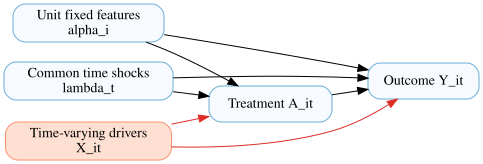

In [2]:
dot = Digraph("panel_fe", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("Unit", "Unit fixed features\nalpha_i")
dot.node("Time", "Common time shocks\nlambda_t")
dot.node("A", "Treatment A_it")
dot.node("Y", "Outcome Y_it")
dot.node("TV", "Time-varying drivers\nX_it", fillcolor="#fee0d2", color="#fc9272")

dot.edge("Unit", "A")
dot.edge("Unit", "Y")
dot.edge("Time", "A")
dot.edge("Time", "Y")
dot.edge("A", "Y")
dot.edge("TV", "A", color="#de2d26")
dot.edge("TV", "Y", color="#de2d26")

dot


The red node is the warning. Fixed effects handle stable unit differences and common time shocks. They do not automatically handle time-varying factors that affect both treatment and outcome.

repeated observations create both power and risk. Time-varying confounding, lagged outcomes, and changing composition all shape the estimand.

## 3. A Clean Two-Period Difference-in-Differences Example

The canonical difference-in-differences design has:

- two groups,
- two periods,
- one group becomes treated,
- the other remains untreated.

The identifying assumption is parallel trends:

$$
E[Y_{1}(0) - Y_{0}(0) \mid G=1]
=
E[Y_{1}(0) - Y_{0}(0) \mid G=0]
$$

That says treated and comparison groups would have had the same average change absent treatment.


In [3]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4707)
n_per_group = 900
true_tau = 2.0

rows = []
for group in [0, 1]:
    unit_effect = rng.normal(0, 1.2, size=n_per_group)
    for unit in range(n_per_group):
        for t in [0, 1]:
            treated = int(group == 1 and t == 1)
            common_time = 1.1 * t
            y0 = 8 + 1.8 * group + common_time + unit_effect[unit] + rng.normal(0, 1.0)
            y = y0 + true_tau * treated
            rows.append({"unit": f"{group}_{unit}", "group": group, "time": t, "treated": treated, "Y": y})

did_simple = pd.DataFrame(rows)

did_means = did_simple.groupby(["group", "time"], as_index=False)["Y"].mean()
did_wide = did_means.pivot(index="group", columns="time", values="Y")
manual_did = (did_wide.loc[1, 1] - did_wide.loc[1, 0]) - (did_wide.loc[0, 1] - did_wide.loc[0, 0])

twfe_simple = smf.ols("Y ~ treated + C(unit) + C(time)", data=did_simple).fit()

pd.Series(
    {
        "manual_DiD": manual_did,
        "TWFE_coefficient": twfe_simple.params["treated"],
        "true_effect": true_tau,
    }
)


manual_DiD         1.899
TWFE_coefficient   1.899
true_effect        2.000
dtype: float64

This result clarifies how far the method can carry the claim. Panels create power and risk at the same time. Time-varying confounding, lags, and changing composition all shape the estimand.

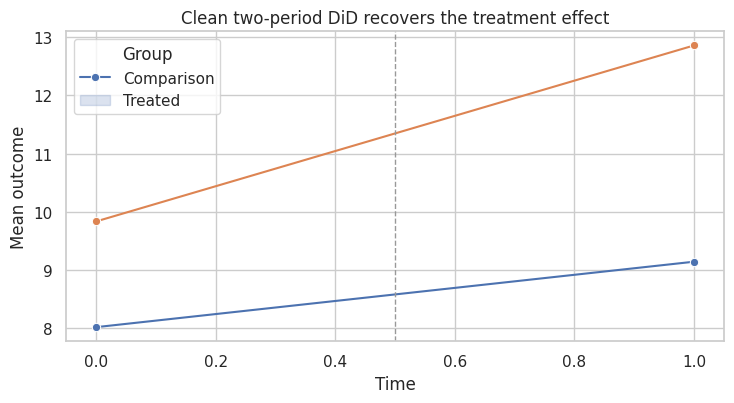

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.lineplot(data=did_means, x="time", y="Y", hue="group", marker="o", ax=ax)
ax.axvline(0.5, color="#999999", linestyle="--", linewidth=1)
ax.set_title("Clean two-period DiD recovers the treatment effect")
ax.set_xlabel("Time")
ax.set_ylabel("Mean outcome")
ax.legend(title="Group", labels=["Comparison", "Treated"])
plt.tight_layout()
plt.show()


This is the friendly case. The treated group starts higher, but fixed group differences are fine. The key is that untreated potential outcome trends are parallel.

repeated observations create both power and risk. Time-varying confounding, lagged outcomes, and changing composition all shape the estimand.

## 4. Serial Correlation and Standard Errors

Panel outcomes are usually serially correlated. A store with high sales this week tends to have high sales next week. A state with high wages this year tends to have high wages next year.

Bertrand, Duflo, and Mullainathan (2004) show that difference-in-differences designs can severely understate uncertainty when serial correlation is ignored.

The problem is especially acute because treatment indicators in policy panels are often persistent:

$$
A_{it} = 1 \quad \text{for all periods after adoption}
$$

That means both the outcome residuals and the treatment can be serially correlated.


In [5]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4708)
n_units = 120
n_periods = 16
rho = 0.78
placebo_tau = 0.0

rows = []
for unit in range(n_units):
    unit_fe = rng.normal(0, 1.0)
    trend = rng.normal(0.02, 0.03)
    adoption = rng.choice([8, 9, 10, 11, 99], p=[0.15, 0.20, 0.20, 0.15, 0.30])
    eps_prev = rng.normal(0, 1)
    for t in range(n_periods):
        eps = rho * eps_prev + rng.normal(0, 1)
        eps_prev = eps
        treated = int(t >= adoption)
        y = 5 + unit_fe + 0.25 * t + trend * t + placebo_tau * treated + eps
        rows.append({"unit": unit, "time": t, "treated": treated, "Y": y})

serial_df = pd.DataFrame(rows)

naive_model = smf.ols("Y ~ treated + C(unit) + C(time)", data=serial_df).fit()
cluster_model = smf.ols("Y ~ treated + C(unit) + C(time)", data=serial_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": serial_df["unit"]},
)

serial_results = pd.DataFrame(
    {
        "Naive OLS standard error": coef_row(naive_model, "treated"),
        "Clustered by unit": coef_row(cluster_model, "treated"),
    }
).T

serial_results


,estimate,std_error,ci_lower,ci_upper,p_value
Naive OLS standard error,0.147,0.111,-0.070,0.364,0.184
Clustered by unit,0.147,0.235,-0.314,0.608,0.532


In an applied workflow, the main point is direct. Repeated observations help, but they also create dynamic threats that a simple fixed-effect model can miss.

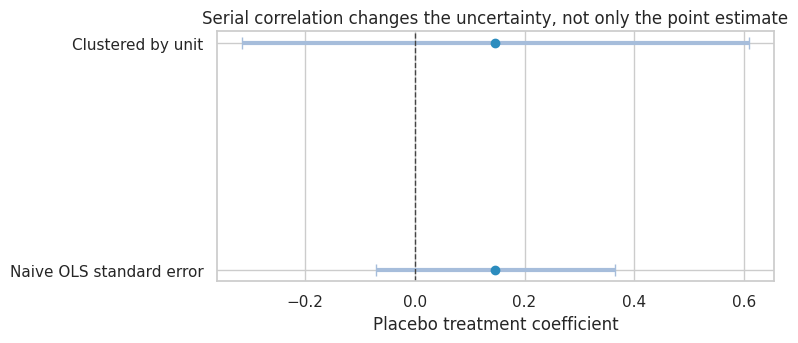

In [6]:
plot_coef_table(
    serial_results,
    title="Serial correlation changes the uncertainty, not only the point estimate",
    xlabel="Placebo treatment coefficient",
    reference=0,
    figsize=(8, 3.6),
)
plt.show()


The treatment has no effect in this simulation. The point estimate can wander because of serially correlated shocks. The naive standard error treats many repeated observations as more independent than they really are.

In applied work, cluster at the level where treatment varies or where shocks are correlated. For policies assigned to units over time, unit-level clustering is often the minimum. With few clusters, use randomization inference, wild cluster bootstrap, or design-based inference to avoid mechanical reliance on asymptotics.


## 5. Dynamic Panels and Nickell Bias

A common panel model includes lagged outcomes:

$$
Y_{it} = \alpha_i + \rho Y_{i,t-1} + \epsilon_{it}
$$

With fixed effects and short panels, the within estimator for $\rho$ is biased. This is often called Nickell bias after Nickell (1981).

The intuition: demeaning by unit uses each unit's full time series, which makes the transformed lagged outcome mechanically related to the transformed error.


In [7]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
def simulate_dynamic_panel(n_units=500, n_periods=6, rho=0.65, seed=1):
    """Simulate a short operational panel with persistence and calendar pressure.
    
    Inputs:
    - `n_units`: number of panel units, accounts, stores, or regions in the simulated dataset.
    - `n_periods`: number of time periods observed for each unit in the panel.
    - `rho`: rho value used by `simulate_dynamic_panel`.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: a pandas DataFrame with unit-time outcomes, lagged outcomes, workload, account size, service complexity, and calendar shocks."""
    rng = np.random.default_rng(seed)
    calendar_shocks = 0.25 * np.sin(np.arange(n_periods) / 1.7) + rng.normal(0, 0.18, size=n_periods)
    rows = []
    for unit in range(n_units):
        alpha = rng.normal(0, 1.0)
        account_size = rng.lognormal(mean=0.2, sigma=0.45)
        service_complexity = rng.normal(0, 1.0)
        unit_trend = rng.normal(0.015, 0.025)
        workload_prev = rng.normal(0, 1.0)
        y_prev = alpha / (1 - rho) + 0.25 * service_complexity + rng.normal(0, 1.0)
        for t in range(n_periods):
            workload = 0.60 * workload_prev + 0.20 * service_complexity + rng.normal(0, 0.75)
            y = (
                0.4
                + alpha
                + rho * y_prev
                + unit_trend * t
                + 0.28 * workload
                + 0.18 * np.log1p(account_size)
                + calendar_shocks[t]
                + rng.normal(0, 1.0)
            )
            rows.append(
                {
                    "unit": unit,
                    "time": t,
                    "Y": y,
                    "Y_lag": y_prev,
                    "workload": workload,
                    "account_size": account_size,
                    "service_complexity": service_complexity,
                    "calendar_shock": calendar_shocks[t],
                }
            )
            y_prev = y
            workload_prev = workload
    return pd.DataFrame(rows)


def within_lag_estimate(df):
    """Estimate the within-transformed lag coefficient in a dynamic panel.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    Returns: a scalar fixed-effects lag estimate used to illustrate Nickell bias."""
    work = df.loc[df["time"] > 0].copy()
    y_dm = demean_by_group(work["Y"].to_numpy(), work["unit"])
    lag_dm = demean_by_group(work["Y_lag"].to_numpy(), work["unit"])
    model = sm.OLS(y_dm, lag_dm).fit()
    return model.params[0]


dynamic_rows = []
for periods in [4, 6, 10, 20, 40]:
    estimates = []
    for rep in range(40):
        tmp = simulate_dynamic_panel(n_units=350, n_periods=periods, rho=0.65, seed=1000 + 10 * periods + rep)
        estimates.append(within_lag_estimate(tmp))
    dynamic_rows.append(
        {
            "periods": periods,
            "mean_within_estimate": np.mean(estimates),
            "p10": np.quantile(estimates, 0.10),
            "p90": np.quantile(estimates, 0.90),
            "true_rho": 0.65,
        }
    )

nickell_table = pd.DataFrame(dynamic_rows)
nickell_table["bias"] = nickell_table["mean_within_estimate"] - nickell_table["true_rho"]
nickell_table


,periods,mean_within_estimate,p10,p90,true_rho,bias
0,4,0.203,0.119,0.291,0.650,-0.447
1,6,0.368,0.301,0.446,0.650,-0.282
2,10,0.481,0.452,0.510,0.650,-0.169
3,20,0.634,0.615,0.655,0.650,-0.016
4,40,0.757,0.744,0.769,0.650,0.107


This result should affect the next modeling or decision step. The panel structure should clarify trends, timing, and composition before it is used for causal leverage.

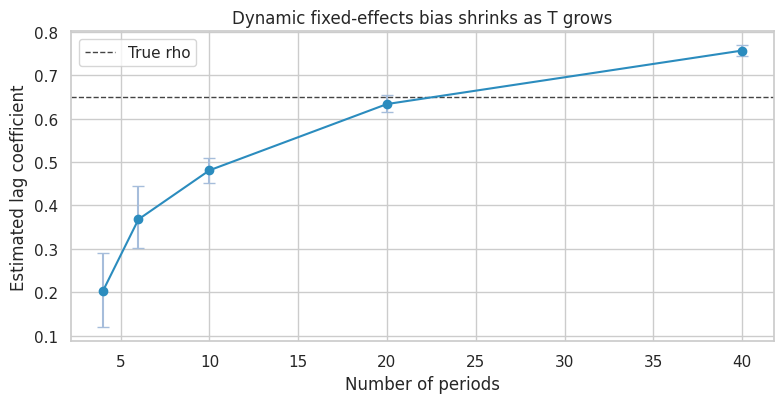

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.errorbar(
    nickell_table["periods"],
    nickell_table["mean_within_estimate"],
    yerr=[
        nickell_table["mean_within_estimate"] - nickell_table["p10"],
        nickell_table["p90"] - nickell_table["mean_within_estimate"],
    ],
    fmt="o-",
    color="#2b8cbe",
    ecolor="#a6bddb",
    capsize=4,
)
ax.axhline(0.65, color="#444444", linestyle="--", linewidth=1, label="True rho")
ax.set_title("Dynamic fixed-effects bias shrinks as T grows")
ax.set_xlabel("Number of periods")
ax.set_ylabel("Estimated lag coefficient")
ax.legend()
plt.tight_layout()
plt.show()


### Practical Takeaway

Lagged outcomes are not harmless controls in short panels. They can:

- change the estimand,
- absorb treatment effects,
- introduce dynamic panel bias,
- create post-treatment adjustment if treatment affects lagged outcomes.

Use lagged outcomes deliberately. If the model is dynamic and $T$ is small, consider designs and estimators built for dynamic panels before defaulting to fixed effects plus lagged outcome.


## 6. Staggered Adoption

In industry and policy settings, treatment often arrives at different times:

- stores adopt a tool in waves,
- sales teams receive training on different dates,
- markets launch a product feature gradually,
- customers migrate to a new billing system in cohorts.

With staggered adoption, a simple two-way fixed-effects model is:

$$
Y_{it} = \alpha_i + \lambda_t + \tau D_{it} + \epsilon_{it}
$$

where $D_{it}=1$ after adoption.

Goodman-Bacon (2021), de Chaisemartin and D'Haultfoeuille (2020), Callaway and Sant'Anna (2021), Sun and Abraham (2021), and Borusyak, Jaravel, and Spiess (2024) all study why conventional TWFE/event-study estimators can be difficult to interpret under staggered timing and heterogeneous effects.


In [9]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4710)
n_units = 520
n_periods = 10
cohort_choices = np.array([4, 6, 8, 99])
cohort_probs = np.array([0.28, 0.27, 0.25, 0.20])
cohorts = rng.choice(cohort_choices, size=n_units, p=cohort_probs)

rows = []
for unit, cohort in enumerate(cohorts):
    unit_fe = rng.normal(0, 1.1)
    unit_slope = rng.normal(0.03, 0.04)
    size = rng.normal(0, 1)
    for t in range(n_periods):
        treated = int(t >= cohort)
        event_time = t - cohort if cohort < 99 else np.nan
        base = 10 + unit_fe + 0.35 * t + unit_slope * t + 0.5 * size
        if treated:
            # Effects grow with exposure length and are larger for earlier adopters.
            exposure_length = t - cohort + 1
            cohort_multiplier = {4: 1.25, 6: 1.00, 8: 0.70}[cohort]
            tau = cohort_multiplier * (0.6 + 0.55 * exposure_length)
        else:
            tau = 0.0
        y = base + tau + rng.normal(0, 1.0)
        rows.append(
            {
                "unit": unit,
                "time": t,
                "cohort": cohort,
                "treated": treated,
                "event_time": event_time,
                "size": size,
                "true_tau": tau,
                "Y": y,
            }
        )

staggered = pd.DataFrame(rows)
staggered["cohort_label"] = staggered["cohort"].replace({99: "Never"})

cohort_summary = staggered.groupby("cohort_label").agg(
    units=("unit", "nunique"),
    first_treated=("cohort", "first"),
    true_att=("true_tau", lambda s: s[s > 0].mean()),
).reset_index()

true_att = staggered.loc[staggered["treated"] == 1, "true_tau"].mean()
twfe_staggered = smf.ols("Y ~ treated + C(unit) + C(time)", data=staggered).fit(
    cov_type="cluster",
    cov_kwds={"groups": staggered["unit"]},
)

cohort_summary, pd.Series({"true_ATT_over_treated_cells": true_att, "TWFE_coefficient": twfe_staggered.params["treated"]})


(  cohort_label  units  first_treated  true_att
 0            4    143              4     3.156
 1            6    141              6     1.975
 2            8    121              8     0.997
 3        Never    115             99       NaN,
 true_ATT_over_treated_cells   2.442
 TWFE_coefficient              1.623
 dtype: float64)

This is where the method earns trust from the data. Panels create power and risk at the same time. Time-varying confounding, lags, and changing composition all shape the estimand.

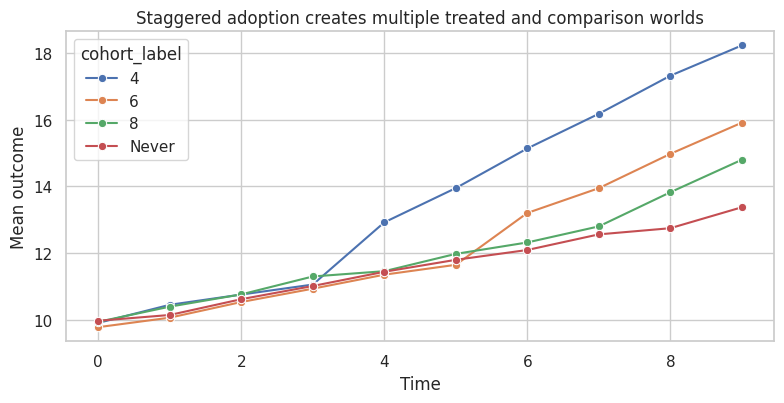

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.2))
mean_paths = staggered.groupby(["cohort_label", "time"], as_index=False)["Y"].mean()
sns.lineplot(data=mean_paths, x="time", y="Y", hue="cohort_label", marker="o", ax=ax)
ax.set_title("Staggered adoption creates multiple treated and comparison worlds")
ax.set_xlabel("Time")
ax.set_ylabel("Mean outcome")
plt.tight_layout()
plt.show()


The TWFE coefficient is a single number. But the simulated treatment effects are dynamic and differ by adoption cohort. A single coefficient can average across effects in ways that are not the simple average effect among treated observations.


## 7. A Simple Group-Time DiD Alternative

One transparent alternative is to estimate group-time treatment effects.

For adoption cohort $g$ at time $t \ge g$, compare the cohort's change from its last pre-treatment period $g-1$ to the change among units not yet treated at time $t$:

$$
ATT(g,t)
=
E[Y_t - Y_{g-1} \mid G=g]
-
E[Y_t - Y_{g-1} \mid G>t]
$$

This is a simplified version of the logic in modern staggered DiD estimators. It is a teaching version, and it makes the estimand much clearer.


In [11]:
# Assemble the summary table used to interpret the causal comparison.
def group_time_att(df):
    """Compute transparent group-time ATT estimates for staggered adoption.
    
    Inputs:
    - `df`: pandas DataFrame containing the observed or simulated data used by this estimator, plot, or diagnostic.
    Returns: a DataFrame of cohort-time treatment effects with control counts and true-cell effects."""
    results = []
    for g in sorted([c for c in df["cohort"].unique() if c < 99]):
        baseline_t = int(g - 1)
        cohort_units = df.loc[df["cohort"] == g, "unit"].unique()
        baseline_cohort = df.loc[(df["unit"].isin(cohort_units)) & (df["time"] == baseline_t), ["unit", "Y"]]
        baseline_cohort = baseline_cohort.rename(columns={"Y": "Y_base"})
        for t in range(int(g), df["time"].max() + 1):
            controls = df.loc[df["cohort"] > t, "unit"].unique()
            if len(controls) == 0:
                continue
            cohort_now = df.loc[(df["unit"].isin(cohort_units)) & (df["time"] == t), ["unit", "Y"]].merge(
                baseline_cohort,
                on="unit",
            )
            control_base = df.loc[(df["unit"].isin(controls)) & (df["time"] == baseline_t), ["unit", "Y"]].rename(
                columns={"Y": "Y_base"}
            )
            control_now = df.loc[(df["unit"].isin(controls)) & (df["time"] == t), ["unit", "Y"]].merge(
                control_base,
                on="unit",
            )
            att_hat = (cohort_now["Y"] - cohort_now["Y_base"]).mean() - (
                control_now["Y"] - control_now["Y_base"]
            ).mean()
            true_cell_att = df.loc[(df["unit"].isin(cohort_units)) & (df["time"] == t), "true_tau"].mean()
            results.append(
                {
                    "cohort": int(g),
                    "time": t,
                    "event_time": t - int(g),
                    "n_treated_units": len(cohort_units),
                    "n_control_units": len(controls),
                    "att_hat": att_hat,
                    "true_att": true_cell_att,
                }
            )
    return pd.DataFrame(results)


att_gt = group_time_att(staggered)
simple_att = np.average(att_gt["att_hat"], weights=att_gt["n_treated_units"])
simple_true = np.average(att_gt["true_att"], weights=att_gt["n_treated_units"])

staggered_results = pd.DataFrame(
    [
        {"method": "True ATT over treated cells", "estimate": true_att},
        {"method": "TWFE single coefficient", "estimate": twfe_staggered.params["treated"]},
        {"method": "Group-time DiD weighted average", "estimate": simple_att},
        {"method": "True ATT over estimated group-time cells", "estimate": simple_true},
    ]
)
staggered_results["error_vs_true_att"] = staggered_results["estimate"] - true_att
staggered_results


,method,estimate,error_vs_true_att
0,True ATT over treated cells,2.442,0.000
1,TWFE single coefficient,1.623,-0.819
2,Group-time DiD weighted average,2.502,0.060
3,True ATT over estimated group-time cells,2.442,0.000


The point is to connect the number to the decision it supports. Repeated observations help, but they also create dynamic threats that a simple fixed-effect model can miss.

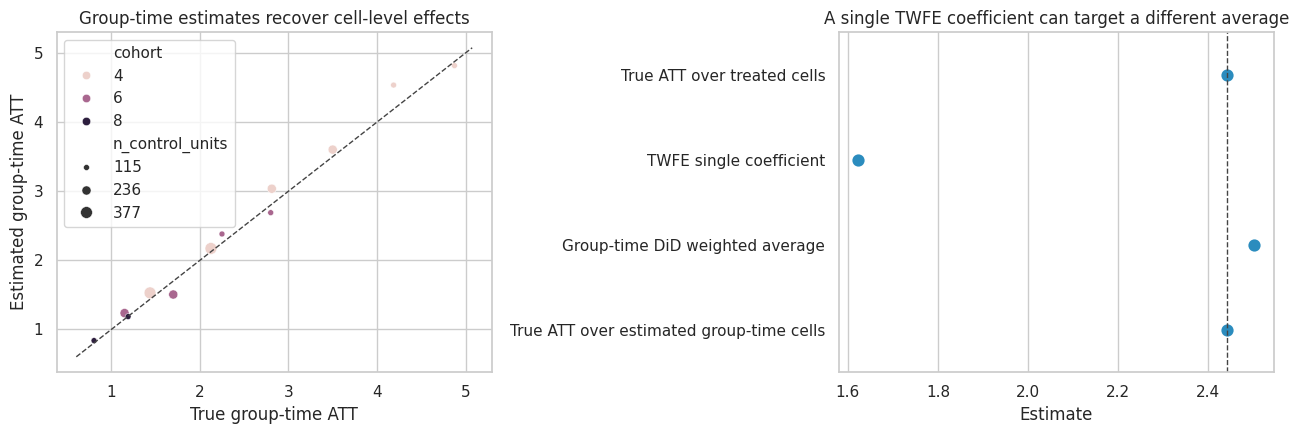

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.scatterplot(data=att_gt, x="true_att", y="att_hat", hue="cohort", size="n_control_units", ax=axes[0])
lims = [
    min(att_gt["true_att"].min(), att_gt["att_hat"].min()) - 0.2,
    max(att_gt["true_att"].max(), att_gt["att_hat"].max()) + 0.2,
]
axes[0].plot(lims, lims, color="#444444", linestyle="--", linewidth=1)
axes[0].set_title("Group-time estimates recover cell-level effects")
axes[0].set_xlabel("True group-time ATT")
axes[0].set_ylabel("Estimated group-time ATT")

sns.pointplot(data=staggered_results, y="method", x="estimate", join=False, ax=axes[1], color="#2b8cbe")
axes[1].axvline(true_att, color="#444444", linestyle="--", linewidth=1)
axes[1].set_title("A single TWFE coefficient can target a different average")
axes[1].set_xlabel("Estimate")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


The group-time table is also a diagnostic object. It shows which cohort-time cells are driving the result and how much comparison support each cell has.

repeated observations create both power and risk. Time-varying confounding, lagged outcomes, and changing composition all shape the estimand.

## 8. Event Studies: Useful but Not Automatic Proof

Event studies estimate effects by relative time:

$$
k = t - G_i
$$

The usual plot shows coefficients for leads and lags around adoption. Leads are often used as a pre-trend diagnostic, while lags show dynamic effects.

Under staggered timing and heterogeneous effects, conventional TWFE event-study coefficients can be contaminated by effects from other periods, as emphasized by Sun and Abraham (2021).


In [13]:
# Fit the models for this section and assemble the estimates used in the discussion.
event_df = staggered.copy()
event_df["event_capped"] = event_df["event_time"].clip(-3, 4)
event_terms = []
for k in [-3, -2, 0, 1, 2, 3, 4]:
    name = f"event_{'m' + str(abs(k)) if k < 0 else 'p' + str(k)}"
    event_df[name] = ((event_df["event_capped"] == k) & (event_df["cohort"] < 99)).astype(int)
    event_terms.append((k, name))

formula = "Y ~ " + " + ".join(name for _, name in event_terms) + " + C(unit) + C(time)"
event_model = smf.ols(formula, data=event_df).fit(cov_type="cluster", cov_kwds={"groups": event_df["unit"]})

twfe_event = pd.DataFrame(
    [
        {
            "event_time": k,
            "estimate": event_model.params[name],
            "std_error": event_model.bse[name],
            "ci_lower": event_model.params[name] - 1.96 * event_model.bse[name],
            "ci_upper": event_model.params[name] + 1.96 * event_model.bse[name],
            "method": "TWFE event-study coefficient",
        }
        for k, name in event_terms
    ]
)

gt_event = (
    att_gt.groupby("event_time")
    .apply(lambda d: pd.Series({"estimate": np.average(d["att_hat"], weights=d["n_treated_units"])}))
    .reset_index()
)
gt_event["method"] = "Group-time event average"
gt_event = gt_event.loc[gt_event["event_time"].between(0, 4)]

twfe_event, gt_event


(   event_time  estimate  std_error  ci_lower  ci_upper  \
 0          -3     0.156      0.074     0.011     0.302   
 1          -2     0.143      0.092    -0.037     0.323   
 2           0     1.348      0.100     1.152     1.545   
 3           1     1.687      0.085     1.522     1.853   
 4           2     2.812      0.112     2.591     3.032   
 5           3     3.185      0.104     2.982     3.389   
 6           4     4.795      0.126     4.548     5.042   
 
                          method  
 0  TWFE event-study coefficient  
 1  TWFE event-study coefficient  
 2  TWFE event-study coefficient  
 3  TWFE event-study coefficient  
 4  TWFE event-study coefficient  
 5  TWFE event-study coefficient  
 6  TWFE event-study coefficient  ,
    event_time  estimate                    method
 0           0     1.222  Group-time event average
 1           1     1.646  Group-time event average
 2           2     2.711  Group-time event average
 3           3     3.149  Group-time even

Here the example becomes operational. The panel structure should clarify trends, timing, and composition before it is used for causal leverage.

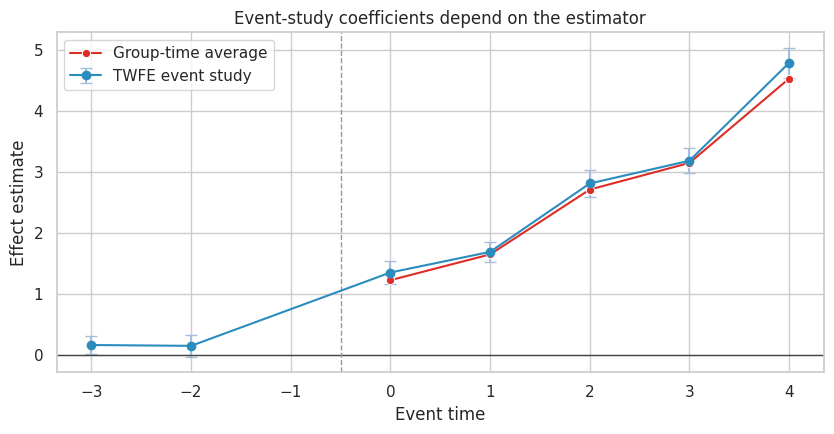

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.errorbar(
    twfe_event["event_time"],
    twfe_event["estimate"],
    yerr=[
        twfe_event["estimate"] - twfe_event["ci_lower"],
        twfe_event["ci_upper"] - twfe_event["estimate"],
    ],
    fmt="o-",
    color="#2b8cbe",
    ecolor="#a6bddb",
    capsize=4,
    label="TWFE event study",
)
sns.lineplot(data=gt_event, x="event_time", y="estimate", marker="o", ax=ax, color="#de2d26", label="Group-time average")
ax.axhline(0, color="#444444", linewidth=1)
ax.axvline(-0.5, color="#999999", linestyle="--", linewidth=1)
ax.set_title("Event-study coefficients depend on the estimator")
ax.set_xlabel("Event time")
ax.set_ylabel("Effect estimate")
ax.legend()
plt.tight_layout()
plt.show()


Event-study plots remain valuable. They force analysts to show dynamics and pre-period behavior. But the plotted coefficient must match a defensible estimand.

repeated observations create both power and risk. Time-varying confounding, lagged outcomes, and changing composition all shape the estimand.

## 9. Anticipation

Parallel trends can fail before treatment if units change behavior in anticipation of treatment.

Examples:

- sales teams prepare before a new compensation plan launches,
- customers delay purchases before a known discount,
- stores change staffing before a new operations tool goes live,
- users migrate behavior before a product sunset.

If anticipation starts at $k=-1$, then using that period as the baseline can hide part of the effect.


In [15]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4712)
n_units = 360
n_periods = 9
rows = []
for unit in range(n_units):
    cohort = rng.choice([5, 99], p=[0.55, 0.45])
    unit_fe = rng.normal(0, 1)
    for t in range(n_periods):
        treated = int(t >= cohort)
        anticipation = int(cohort < 99 and t == cohort - 1)
        effect = 0.8 * anticipation + 2.0 * treated
        y = 7 + unit_fe + 0.4 * t + effect + rng.normal(0, 1)
        rows.append({"unit": unit, "time": t, "cohort": cohort, "treated": treated, "anticipation": anticipation, "Y": y})

anticipation_df = pd.DataFrame(rows)
anticipation_df["event_time"] = anticipation_df["time"] - anticipation_df["cohort"]
anticipation_df.loc[anticipation_df["cohort"] == 99, "event_time"] = np.nan

for k in [-3, -2, -1, 0, 1, 2, 3]:
    name = f"ev_{'m' + str(abs(k)) if k < 0 else 'p' + str(k)}"
    anticipation_df[name] = ((anticipation_df["event_time"] == k) & (anticipation_df["cohort"] < 99)).astype(int)

anticipation_formula = "Y ~ ev_m3 + ev_m2 + ev_m1 + ev_p0 + ev_p1 + ev_p2 + ev_p3 + C(unit) + C(time)"
anticipation_model = smf.ols(anticipation_formula, data=anticipation_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": anticipation_df["unit"]},
)

anticipation_event = pd.DataFrame(
    [
        {
            "event_time": k,
            "estimate": anticipation_model.params[f"ev_{'m' + str(abs(k)) if k < 0 else 'p' + str(k)}"],
            "std_error": anticipation_model.bse[f"ev_{'m' + str(abs(k)) if k < 0 else 'p' + str(k)}"],
        }
        for k in [-3, -2, -1, 0, 1, 2, 3]
    ]
)
anticipation_event["ci_lower"] = anticipation_event["estimate"] - 1.96 * anticipation_event["std_error"]
anticipation_event["ci_upper"] = anticipation_event["estimate"] + 1.96 * anticipation_event["std_error"]
anticipation_event


,event_time,estimate,std_error,ci_lower,ci_upper
0,-3,0.040,0.136,-0.226,0.307
1,-2,-0.034,0.136,-0.301,0.232
2,-1,0.552,0.133,0.291,0.813
3,0,1.855,0.148,1.564,2.146
4,1,1.985,0.137,1.716,2.255
5,2,1.900,0.133,1.639,2.162
6,3,1.853,0.138,1.582,2.124


This output should make the next modeling choice easier to defend. Panels create power and risk at the same time. Time-varying confounding, lags, and changing composition all shape the estimand.

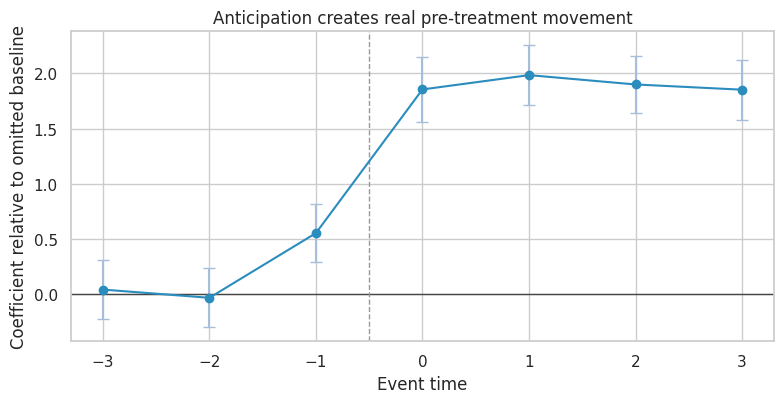

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.errorbar(
    anticipation_event["event_time"],
    anticipation_event["estimate"],
    yerr=[
        anticipation_event["estimate"] - anticipation_event["ci_lower"],
        anticipation_event["ci_upper"] - anticipation_event["estimate"],
    ],
    fmt="o-",
    color="#2b8cbe",
    ecolor="#a6bddb",
    capsize=4,
)
ax.axhline(0, color="#444444", linewidth=1)
ax.axvline(-0.5, color="#999999", linestyle="--", linewidth=1)
ax.set_title("Anticipation creates real pre-treatment movement")
ax.set_xlabel("Event time")
ax.set_ylabel("Coefficient relative to omitted baseline")
plt.tight_layout()
plt.show()


A significant lead is not always "bad data." It can be a real effect before official treatment. The design response is to redefine the treatment window, exclude anticipation periods from the baseline, or estimate anticipation effects explicitly.


## 10. Time-Varying Confounding

Fixed effects do not solve time-varying confounding.

Suppose a risk score changes over time. High-risk units are more likely to receive treatment, and risk also affects outcomes.

Then:

$$
X_{it} \rightarrow A_{it}
$$

and:

$$
X_{it} \rightarrow Y_{it}
$$

Unit and time fixed effects do not block this path because $X_{it}$ varies within unit over time.


In [17]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4713)
n_units = 500
n_periods = 8
rows = []
for unit in range(n_units):
    unit_fe = rng.normal(0, 1)
    risk_prev = rng.normal(0, 1)
    for t in range(n_periods):
        risk = 0.65 * risk_prev + rng.normal(0, 0.8)
        treated = int(risk > 0.75 and t >= 2)
        true_effect = 1.2
        y = 6 + unit_fe + 0.35 * t - 1.5 * risk + true_effect * treated + rng.normal(0, 1)
        rows.append({"unit": unit, "time": t, "risk": risk, "treated": treated, "Y": y, "true_effect": true_effect})
        risk_prev = risk

tvc_df = pd.DataFrame(rows)

tvc_no_covariate = smf.ols("Y ~ treated + C(unit) + C(time)", data=tvc_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": tvc_df["unit"]},
)
tvc_with_covariate = smf.ols("Y ~ treated + risk + C(unit) + C(time)", data=tvc_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": tvc_df["unit"]},
)

tvc_results = pd.DataFrame(
    {
        "TWFE without time-varying risk": coef_row(tvc_no_covariate, "treated"),
        "TWFE adjusting for risk": coef_row(tvc_with_covariate, "treated"),
    }
).T

tvc_results


,estimate,std_error,ci_lower,ci_upper,p_value
TWFE without time-varying risk,-0.789,0.075,-0.935,-0.643,0.000
TWFE adjusting for risk,1.245,0.064,1.120,1.371,0.000


The result is most useful when it shapes the next action. Repeated observations help, but they also create dynamic threats that a simple fixed-effect model can miss.

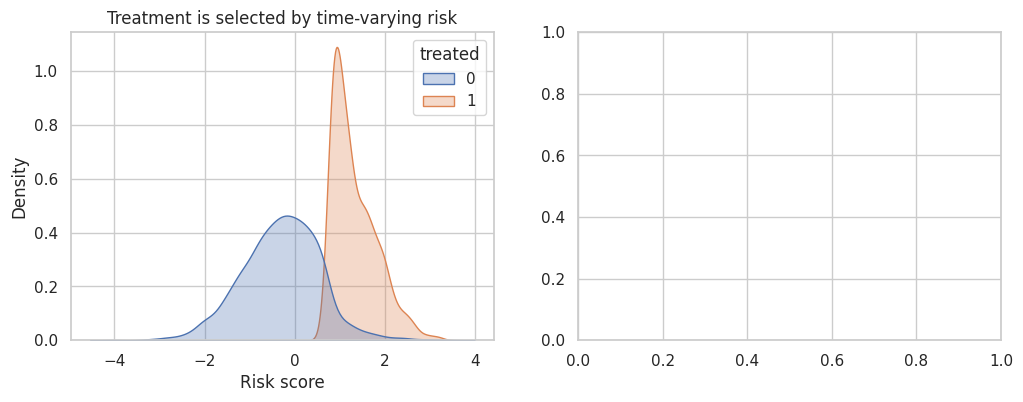

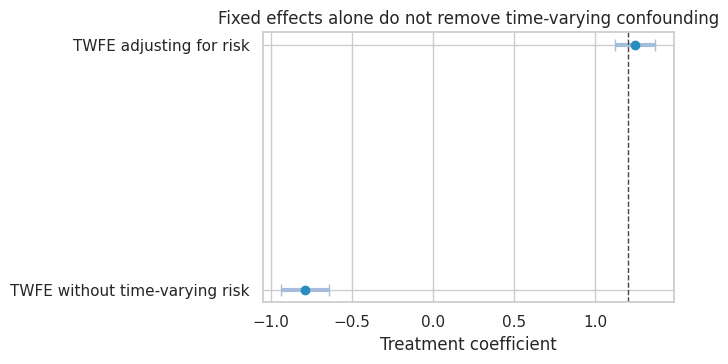

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(data=tvc_df, x="risk", hue="treated", common_norm=False, fill=True, alpha=0.30, ax=axes[0])
axes[0].set_title("Treatment is selected by time-varying risk")
axes[0].set_xlabel("Risk score")

plot_coef_table(
    tvc_results,
    title="Fixed effects alone do not remove time-varying confounding",
    xlabel="Treatment coefficient",
    reference=1.2,
    figsize=(7, 3.8),
)
plt.show()


Adjusting for a time-varying covariate can help if it is pre-treatment at each time and measured well. But if the covariate is affected by prior treatment, ordinary adjustment can introduce post-treatment bias. In that case, consider marginal structural models, g-methods, or a design with cleaner treatment assignment.


## 11. Unbalanced Panels and Attrition

Panel data are often unbalanced:

- customers churn,
- stores close,
- devices stop reporting,
- contracts end,
- users opt out of tracking.

If attrition depends on treatment or outcome potential, complete-case panel analysis can change the estimand.


In [19]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4714)
n_units = 900
n_periods = 7
true_attrition_effect = 1.4
rows = []
for unit in range(n_units):
    unit_fe = rng.normal(0, 1)
    treated_group = rng.binomial(1, 0.5)
    observed = True
    for t in range(n_periods):
        if not observed:
            rows.append({"unit": unit, "time": t, "treated": treated_group, "observed": 0, "Y": np.nan, "Y_full": np.nan})
            continue
        y_full = 10 + unit_fe + 0.25 * t + true_attrition_effect * treated_group + rng.normal(0, 1.1)
        dropout_p = 1 / (1 + np.exp(-(-4.0 + 0.25 * t - 0.35 * y_full + 0.45 * treated_group)))
        observed = rng.binomial(1, 1 - dropout_p) == 1
        y_obs = y_full if observed else np.nan
        rows.append({"unit": unit, "time": t, "treated": treated_group, "observed": int(observed), "Y": y_obs, "Y_full": y_full})

attrition_df = pd.DataFrame(rows)
observed_df = attrition_df.loc[attrition_df["observed"] == 1].copy()

attrition_rate = 1 - attrition_df.groupby("time")["observed"].mean()
complete_case_model = smf.ols("Y ~ treated + C(time)", data=observed_df).fit()
oracle_model = smf.ols("Y_full ~ treated + C(time)", data=attrition_df.dropna(subset=["Y_full"])).fit()

attrition_results = pd.DataFrame(
    {
        "Oracle among generated outcomes": coef_row(oracle_model, "treated"),
        "Observed complete-case panel": coef_row(complete_case_model, "treated"),
    }
).T

attrition_results


,estimate,std_error,ci_lower,ci_upper,p_value
Oracle among generated outcomes,1.523,0.038,1.448,1.598,0.000
Observed complete-case panel,1.523,0.038,1.448,1.597,0.000


This is a checkpoint for the design and the estimate together. The panel structure should clarify trends, timing, and composition before it is used for causal leverage.

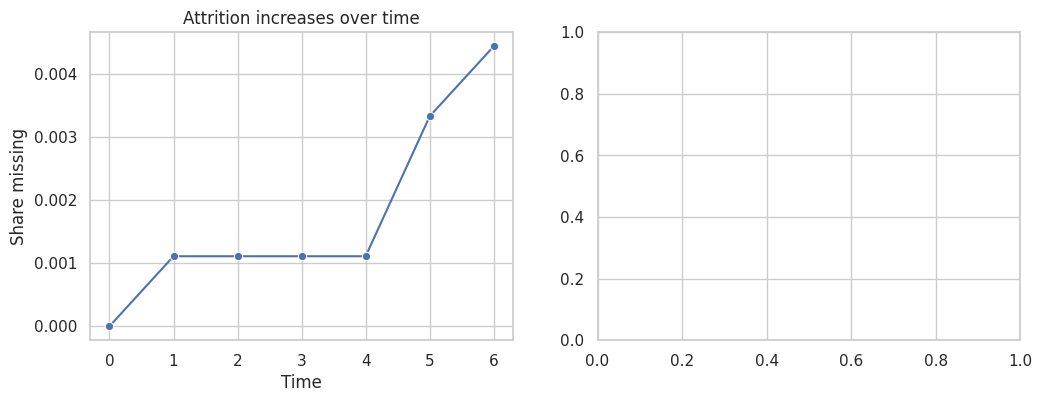

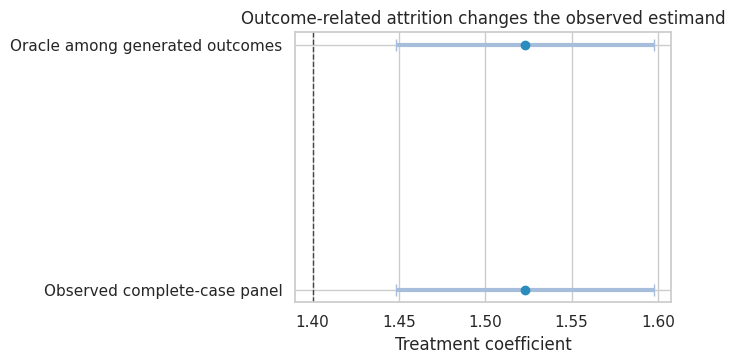

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(x=attrition_rate.index, y=attrition_rate.values, marker="o", ax=axes[0])
axes[0].set_title("Attrition increases over time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Share missing")

plot_coef_table(
    attrition_results,
    title="Outcome-related attrition changes the observed estimand",
    xlabel="Treatment coefficient",
    reference=true_attrition_effect,
    figsize=(7, 3.8),
)
plt.show()


The complete-case estimate is not simply noisier. It is based on a selected panel. If attrition is outcome-related, the remaining observed units are not representative of the original causal target.

A professional panel analysis should report:

- attrition by treatment and time,
- whether missingness is monotone or intermittent,
- whether treatment affects observation,
- sensitivity to missing outcomes,
- weighting or imputation assumptions if used.


## 12. Panel Data Workflow

For industry work, use a design checklist before fitting the regression.


| step | question | example |
|---|---|---|
| Define the unit and time scale | What is one row, and what time interval matters for response? | Customer-week, store-day, account-month. |
| Define treatment timing | Is treatment absorbing, reversible, continuous, staggered, or repeated? | Feature rollout date, pricing exposure, training completion. |
| Draw untreated trends | Do treated and comparison units look plausible before treatment? | Event-time means and cohort-specific pre-trends. |
| Check serial correlation | Are outcomes and treatment persistent? | Cluster by unit or assignment level; consider randomization inference. |
| Check staggered-adoption estimand | Does TWFE average meaningful effects under heterogeneity? | Group-time ATT table and event-study estimator choice. |
| Check anticipation | Could units respond before the official treatment date? | Announcement periods, preparation windows, delayed purchases. |
| Check time-varying confounding | Do time-varying variables drive both treatment and outcome? | Risk score, demand shock, account health, staffing level. |
| Check missingness | Does observation depend on treatment or outcomes? | Churn, telemetry gaps, store closures, customer opt-out. |


## 13. Decision Memo Example

Here is a concise panel-data memo for a staggered rollout.


In [21]:
memo = '''
### Panel Data Causal Memo

**Decision.** Estimate the effect of a new customer-success playbook rolled out to account teams in waves.

**Panel structure.** Account-month panel. Treatment begins when the account's assigned team completes playbook training. Treatment is absorbing.

**Primary estimand.** Average effect among treated account-months during the first six months after rollout.

**Main threats.**

- Rollout timing was not random; high-risk teams were prioritized.
- Account health changes over time and affects both rollout priority and renewal.
- Teams may anticipate training before the official completion date.
- Renewal outcomes are serially correlated within account.

**Design plan.**

- Plot cohort-specific pre-treatment trends in renewal, usage, and account health.
- Estimate group-time ATT values using not-yet-treated and never-treated accounts as comparisons.
- Avoid interpreting a single TWFE coefficient as the primary estimand under heterogeneous dynamic effects.
- Cluster uncertainty at the account or team assignment level.
- Treat the month before training as an anticipation window in sensitivity analysis.

**Reporting.**

- Report dynamic effects by months since rollout.
- Report support: number of cohorts, account-months, and available comparison units by event time.
- Show sensitivity to adding pre-treatment account health and excluding anticipation windows.

**Decision rule.**

- Recommend broader rollout only if renewal lift is positive after accounting for rollout selection and if effects persist beyond the initial implementation month.
'''.strip()

display(Markdown(memo))


### Panel Data Causal Memo

**Decision.** Estimate the effect of a new customer-success playbook rolled out to account teams in waves.

**Panel structure.** Account-month panel. Treatment begins when the account's assigned team completes playbook training. Treatment is absorbing.

**Primary estimand.** Average effect among treated account-months during the first six months after rollout.

**Main threats.**

- Rollout timing was not random; high-risk teams were prioritized.
- Account health changes over time and affects both rollout priority and renewal.
- Teams may anticipate training before the official completion date.
- Renewal outcomes are serially correlated within account.

**Design plan.**

- Plot cohort-specific pre-treatment trends in renewal, usage, and account health.
- Estimate group-time ATT values using not-yet-treated and never-treated accounts as comparisons.
- Avoid interpreting a single TWFE coefficient as the primary estimand under heterogeneous dynamic effects.
- Cluster uncertainty at the account or team assignment level.
- Treat the month before training as an anticipation window in sensitivity analysis.

**Reporting.**

- Report dynamic effects by months since rollout.
- Report support: number of cohorts, account-months, and available comparison units by event time.
- Show sensitivity to adding pre-treatment account health and excluding anticipation windows.

**Decision rule.**

- Recommend broader rollout only if renewal lift is positive after accounting for rollout selection and if effects persist beyond the initial implementation month.

## 14. Common Failure Modes

1. Treating fixed effects as a universal fix for confounding.
2. Ignoring serial correlation and reporting overly small standard errors.
3. Adding lagged outcomes in short panels without recognizing dynamic panel bias.
4. Using a single TWFE coefficient under staggered adoption and heterogeneous effects.
5. Treating event-study leads as a foolproof pre-trend test.
6. Using an anticipation period as the baseline.
7. Adjusting for time-varying covariates that may be affected by prior treatment.
8. Ignoring attrition and silently changing the target population.
9. Row-level clustering when assignment or shocks occur at a higher level.
10. Reporting a polished regression table without showing cohort-time support.


## 15. Exercises

1. In the serial-correlation simulation, increase $\rho$ to $0.90$. Compare naive and clustered standard errors.
2. In the dynamic panel simulation, set $T=3$. How severe is the lag coefficient bias?
3. In the staggered-adoption simulation, make treatment effects constant across cohorts and event time. What happens to the TWFE coefficient?
4. Modify the group-time estimator to use only never-treated units as controls. How does the estimate change?
5. In the anticipation simulation, use event time $-2$ as the omitted reference period. How does the plot change?
6. In the attrition simulation, make dropout random and unrelated to outcomes. Does complete-case analysis remain biased?
7. For your own panel project, write down the unit, time scale, treatment timing, comparison group, and target estimand before fitting any model.


## 16. Key Takeaways

- Panel data can remove stable unit differences and common time shocks, but not every causal threat.
- Difference-in-differences relies on untreated potential outcome trends, not merely on having before-and-after data.
- Serial correlation matters because panel outcomes and policy treatments are persistent.
- Dynamic fixed-effects models with lagged outcomes can be biased in short panels.
- Staggered adoption plus heterogeneous dynamic effects makes single TWFE coefficients hard to interpret.
- Group-time effects and event-time summaries make the estimand more transparent.
- Anticipation, time-varying confounding, and attrition should be treated as design issues, not afterthoughts.
- A good panel analysis shows trends, support, estimator choice, and sensitivity, not only regression output.


## References

Bertrand, M., Duflo, E., & Mullainathan, S. (2004). How much should we trust differences-in-differences estimates? *The Quarterly Journal of Economics, 119*(1), 249-275. [https://doi.org/10.1162/003355304772839588](https://doi.org/10.1162/003355304772839588)

Borusyak, K., Jaravel, X., & Spiess, J. (2024). Revisiting event-study designs: Robust and efficient estimation. *The Review of Economic Studies, 91*(6), 3253-3285. [https://doi.org/10.1093/restud/rdae007](https://doi.org/10.1093/restud/rdae007)

Callaway, B., & Sant’Anna, P. H. C. (2021). Difference-in-differences with multiple time periods. *Journal of Econometrics, 225*(2), 200-230. [https://doi.org/10.1016/j.jeconom.2020.12.001](https://doi.org/10.1016/j.jeconom.2020.12.001)

de Chaisemartin, C., & D’Haultfœuille, X. (2020). Two-way fixed effects estimators with heterogeneous treatment effects. *American Economic Review, 110*(9), 2964-2996. [https://doi.org/10.1257/aer.20181169](https://doi.org/10.1257/aer.20181169)

Goodman-Bacon, A. (2021). Difference-in-differences with variation in treatment timing. *Journal of Econometrics, 225*(2), 254-277. [https://doi.org/10.1016/j.jeconom.2021.03.014](https://doi.org/10.1016/j.jeconom.2021.03.014)

Nickell, S. (1981). Biases in dynamic models with fixed effects. *Econometrica, 49*(6), 1417-1426. [https://doi.org/10.2307/1911408](https://doi.org/10.2307/1911408)

Sun, L., & Abraham, S. (2021). Estimating dynamic treatment effects in event studies with heterogeneous treatment effects. *Journal of Econometrics, 225*(2), 175-199. [https://doi.org/10.1016/j.jeconom.2020.09.006](https://doi.org/10.1016/j.jeconom.2020.09.006)
